In [2]:
import numpy as np
import matplotlib.pyplot as plt

"""
from qiskit.circuit import ParameterVector
from qiskit.opflow import X, Z, I, Y


from qiskit.algorithms import MinimumEigensolver, VQEResult

from qiskit_ibm_runtime import (QiskitRuntimeService, Session,
                                Estimator as RuntimeEstimator,
                                Sampler as RuntimeSampler,
                                Options)
from qiskit.primitives import Sampler,Estimator
from qiskit import *
from qiskit.visualization import *
from qiskit.algorithms.optimizers import COBYLA,NFT,GradientDescent,ADAM,SPSA
from qiskit.algorithms.minimum_eigensolvers import  VQE
from qiskit.circuit.library import EvolvedOperatorAnsatz,RXXGate,RZZGate

from qiskit.opflow import PauliSumOp, SummedOp, PauliOp
"""


'\nfrom qiskit.circuit import ParameterVector\nfrom qiskit.opflow import X, Z, I, Y\n\n\nfrom qiskit.algorithms import MinimumEigensolver, VQEResult\n\nfrom qiskit_ibm_runtime import (QiskitRuntimeService, Session,\n                                Estimator as RuntimeEstimator,\n                                Sampler as RuntimeSampler,\n                                Options)\nfrom qiskit.primitives import Sampler,Estimator\nfrom qiskit import *\nfrom qiskit.visualization import *\nfrom qiskit.algorithms.optimizers import COBYLA,NFT,GradientDescent,ADAM,SPSA\nfrom qiskit.algorithms.minimum_eigensolvers import  VQE\nfrom qiskit.circuit.library import EvolvedOperatorAnsatz,RXXGate,RZZGate\n\nfrom qiskit.opflow import PauliSumOp, SummedOp, PauliOp\n'

In [3]:
import seaborn as sns
sns.set_theme(style='dark')

In [4]:
Id = np.array([[1, 0],
              [0, 1]])
X_pauli = np.array([[0, 1],
              [1, 0]])
Y_pauli = np.array([[0, -1j],
              [1j, 0]])
Z_pauli = np.array([[1, 0],
              [0, -1]])
H = np.array([[1, 1],
              [1, -1]]) / np.sqrt(2)
S = np.array([[1, 0],
              [0, 1j]])

CNOT01 = np.array([[1, 0, 0, 0],
                   [0, 1, 0, 0],
                   [0, 0, 0, 1],
                   [0, 0, 1, 0]])
CNOT10 = np.array([[1, 0, 0, 0],
                   [0, 0, 0, 1],
                   [0, 0, 1, 0],
                   [0, 1, 0, 0]])
SWAP = np.array([[1, 0, 0, 0],
                 [0, 0, 1, 0],
                 [0, 1, 0, 0],
                 [0, 0, 0, 1]])

In [11]:
# Define a custome VQE class to orchestra the ansatz, classical optimizers, 
# initial point, callback, and final result
class QiskitVQE(MinimumEigensolver):
    
    def __init__(self,estimator, ansatz, optimizer,ham,initial_parameters=None,callback=None):
        self._estimator = estimator
        self._circuit = ansatz
        self._optimizer = optimizer
        self._callback = callback
        self._initial_parameters=initial_parameters
        self._obs=ham

        
    def compute_minimum_eigenvalue(self):
                
        # Define objective function to classically minimize over
        def objective(x):
            job = self._estimator.run(self._circuit,self._obs,[x])
            H=job.result().values[0]
            
            if self._callback is not None:
                self._callback([H,x])
            return H
            
        # Select an initial point for the ansatzs' parameters
        if self._initial_parameters is None:
            x0 = np.pi/2 * np.random.rand(self._circuit.num_parameters)
            
        else:
            x0=self._initial_parameters
        
        # Run optimization
        res = self._optimizer.minimize(objective, x0=x0)

        job = self._estimator.run(self._circuit,self._obs,[res.x])
        H=job.result().values[0]

        return H

NameError: name 'MinimumEigensolver' is not defined

In [12]:
def Lipkin_J1(E,V):
    H=np.array([[-E, -V],
                  [-V, E]])
    
    return H

In [13]:
def Lipkin_J1_pauli(E,V):
    H=-E*Z-V*X
    
    return H

In [14]:
def Lipkin_J2_decomposition(E,V,W):
    H_135=np.array([[-2*E, np.sqrt(6)*V, 0],
                    [np.sqrt(6)*V, 4*W, np.sqrt(6)*V],
                    [0,np.sqrt(6)*V, 2*E]])
    
    H_24=np.array([[-E+3*W, -V],
                  [-V, E+3*W]])
    
    return H_135,H_24

In [15]:
def Lipkin_J2_decomposition_Pauli(E,V,W):
    term1 = W * (I ^ I)
    term2 = (W-E) * (Z ^ I)
    term3 = -(W+E) * (I ^ Z)
    term4 = -W * (Z ^ Z)
    term5 = np.sqrt(6)/2*V * (I ^ X)
    term6 = np.sqrt(6)/2*V * (X ^ I)
    term7 = np.sqrt(6)/2*V * (Z ^ X)
    term8 = -np.sqrt(6)/2*V * (X ^ Z)

    
    H_135= term1+term2+term3+term4+term5+term6+term7+term8

    H_24=3*W*I-E*Z+3*V*X
    return H_135,H_24

In [16]:
Lipkin_J2_decomposition_Pauli(1,1,0)[0]

NameError: name 'I' is not defined

In [17]:
lambdas=np.arange(0.1,4/3,0.01)

vals0=[[],[],[]]
vals1=[[],[]]

for l in lambdas:
    H0,H1=Lipkin_J2_decomposition(1,l,0)
    val0,vecs0=np.linalg.eigh(H0)
    for i,v in enumerate(val0):
        vals0[i].append(v)
    val1,vecs1=np.linalg.eigh(H1)
    for i,v in enumerate(val1):
        vals1[i].append(v)

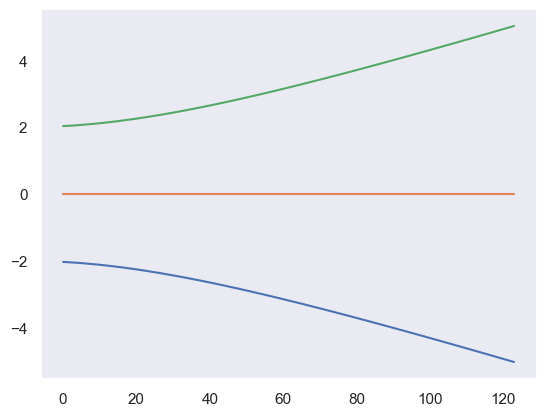

In [14]:
for v in vals0:
    plt.plot(v)

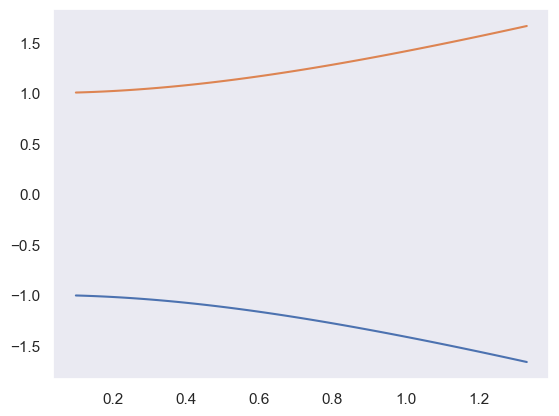

In [15]:
for v in vals1:
    plt.plot(lambdas,v)

In [16]:
def paper_ansatz(N_layers):
    theta = ParameterVector("m",2*N_layers)
    qr=QuantumRegister(2)
    qc=QuantumCircuit(qr)
    k=0
    for _ in range (N_layers):
        qc.ry(theta[k],qr[0])
        k+=1
        qc.cry(theta[k],qr[0],qr[1])
        k+=1
    return qc

/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


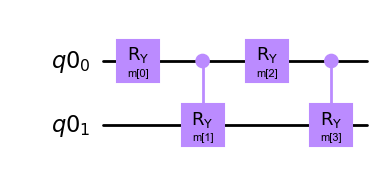

In [17]:
paper_ansatz(2).draw(output='mpl')

In [18]:
def Hamiltonian_ansatz(N_layers):
    theta = ParameterVector("m",8*N_layers)
    qr=QuantumRegister(2)
    qc=QuantumCircuit(qr)
    k=0
    for _ in range (N_layers):
        qc.h(qr[0])
        qc.rzz(theta[k],qr[0],qr[1])
        k+=1
        qc.h(qr[0])
        qc.h(qr[1])
        qc.rzz(theta[k],qr[0],qr[1])
        k+=1
        qc.h(qr[1])
        qc.rx(theta[k],qr[0])
        k+=1
        qc.rx(theta[k],qr[1])
        k+=1
        qc.rz(theta[k],qr[0])
        k+=1
        qc.rz(theta[k],qr[1])
        k+=1
        qc.rzz(theta[k],qr[0],qr[1])
        k+=1
        qc.barrier()
    return qc

/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


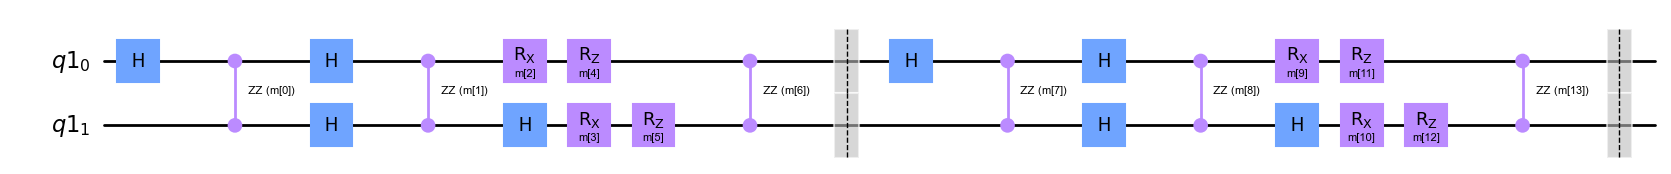

In [19]:
Hamiltonian_ansatz(2).draw(output='mpl')

In [20]:
def separable_ansatz(N_qubits,N_layers):
  theta = ParameterVector("m",2*N_qubits*N_layers)
  qr=QuantumRegister(N_qubits)
  qc=QuantumCircuit(qr)
  k=0
  for _ in range(N_layers):
    for i in range(N_qubits):
        qc.rx(theta[k],qr[i])
        k+=1
        qc.ry(theta[k],qr[i])
        k+=1

  return qc

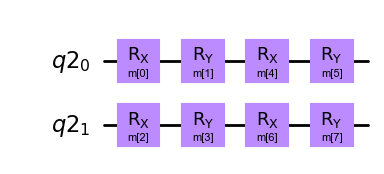

In [21]:
separable_ansatz(2,2).draw(output='mpl')

In [22]:
def Efficient_ansatz(N_qubits,N_layers):
    theta = ParameterVector("m",4*N_qubits*N_layers)
    qr=QuantumRegister(N_qubits)
    qc=QuantumCircuit(qr)
    k=0
    for i in range (N_qubits):
            qc.rx(theta[k],qr[i])
            k+=1
            qc.ry(theta[k],qr[i])
            k+=1
    for i in range (N_qubits-1):
        qc.cx(qr[i],qr[i+1])
    qc.barrier()
    for _ in range (N_layers-1):
        for i in range (N_qubits):
            qc.rx(theta[k],qr[i])
            k+=1
            qc.ry(theta[k],qr[i])
            k+=1
        for i in range (N_qubits-1):
            qc.cx(qr[i],qr[i+1])
        for i in range (N_qubits):
            qc.rx(theta[k],qr[i])
            k+=1
            qc.ry(theta[k],qr[i])
            k+=1
        qc.barrier()
    return qc

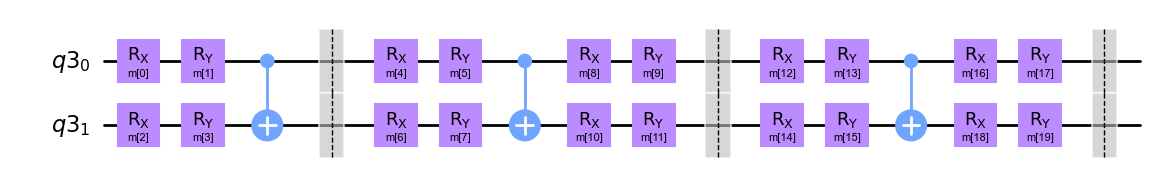

In [23]:
Efficient_ansatz(2,3).draw(output='mpl')

In [24]:
def Real_ansatz(N_qubits,N_layers):
    theta = ParameterVector("theta",4*N_qubits*N_layers)
    qr=QuantumRegister(N_qubits)
    qc=QuantumCircuit(qr)
    k=0
    for i in range (N_qubits):

            qc.ry(theta[k],qr[i])
            k+=1
    for i in range (N_qubits-1):
        qc.cx(qr[i],qr[i+1])
    qc.barrier()
    for _ in range (N_layers-1):
        for i in range (N_qubits):

            qc.ry(theta[k],qr[i])
            k+=1
        for i in range (N_qubits-1):
            qc.cx(qr[i],qr[i+1])
        for i in range (N_qubits):

            qc.ry(theta[k],qr[i])
            k+=1
        qc.barrier()
    return qc

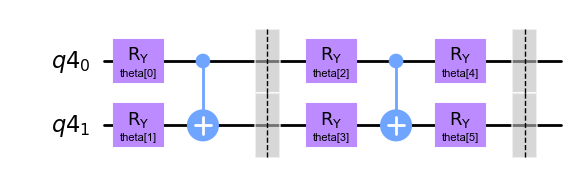

In [25]:
Real_ansatz(2,2).draw(output='mpl')

In [26]:
intermediate_info = []
def callback(data):
                intermediate_info.append(data)

cobyla=COBYLA(maxiter=1000, disp=True, rhobeg=0.1, tol=0.01, options=None)
adam=ADAM(maxiter=300, tol=1e-02, lr=0.1, beta_1=0.9, beta_2=0.99, noise_factor=1e-10, eps=1e-10, amsgrad=True, snapshot_dir=None)
g_d=GradientDescent(maxiter=300,learning_rate=0.1, tol=0.001, callback=None, perturbation=None)
spsa=SPSA(maxiter=100, blocking=False, allowed_increase=None, trust_region=False, learning_rate=None, perturbation=None, last_avg=1, resamplings=1, perturbation_dims=None, callback=None)

In [27]:
E=1
W=0
V=1
H0,H1=Lipkin_J2_decomposition(E,V,W)

val0,vecs0=np.linalg.eigh(H0)
val1,vecs1=np.linalg.eigh(H1)

In [28]:
val0

array([-4.00000000e+00, -1.99389507e-16,  4.00000000e+00])

In [29]:
ansatzs=[Real_ansatz(2,2),Efficient_ansatz(2,2),separable_ansatz(2,2)]
labels=['Real Amplitude Ansatz','Hardware Efficient Ansatz', 'Separable Ansatz']
energies=[]
for ans in ansatzs:
    intermediate_info= []
    initial_parameters=np.ones(ans.num_parameters)*np.pi/2
    estimator = Estimator(options={'shots': None})
    H0,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    custom_vqe = QiskitVQE(estimator,ans,cobyla,H0,initial_parameters=initial_parameters,callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    energies.append(intermediate_info)


   Normal return from subroutine COBYLA

   NFVALS =   51   F =-3.999819E+00    MAXCV = 0.000000E+00
   X = 1.780275E+00   1.700724E+00   1.891664E+00   2.574487E+00   2.104639E+00
       7.417326E-01

   Normal return from subroutine COBYLA

   NFVALS =  106   F =-3.999811E+00    MAXCV = 0.000000E+00
   X = 1.541126E+00   1.533995E+00   9.652188E-01   1.675381E+00   2.313829E+00
       1.589428E+00   1.390075E+00   2.428109E+00   1.413666E+00   3.146415E+00
       1.517604E+00   2.318915E+00

   Normal return from subroutine COBYLA

   NFVALS =   51   F =-3.808351E+00    MAXCV = 0.000000E+00
   X = 1.658651E+00   1.608936E+00   2.188281E+00   1.585451E+00   1.572078E+00
       1.699342E+00   1.580242E+00   2.119636E+00


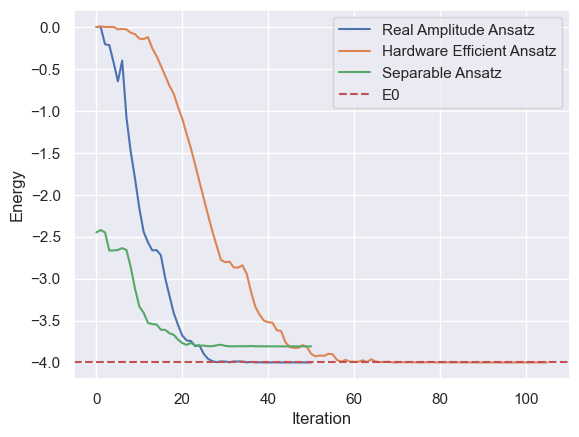

In [30]:
def callback(data):
                intermediate_info.append(data)
for i,opt_info in enumerate(energies):
    en=[]
    param=[]
    for info in opt_info:
        en.append(info[0])
        param.append(info[1])
    plt.plot(en,label=labels[i])
    plt.xlabel('Iteration')
    plt.ylabel('Energy')
plt.axhline(y=val0[0], color='r', linestyle='--',label='E0')
plt.legend()
plt.grid()
plt.savefig('Lipkin_cobyla_ansatz_depth1.pdf')
plt.show()

In [31]:
ansatzs=[Efficient_ansatz(2,1),Efficient_ansatz(2,2),Efficient_ansatz(2,3),Efficient_ansatz(2,4)]
labels=['depth 1','depth 2', 'depth 3','depth 4']
energies=[]
for ans in ansatzs:
    intermediate_info= []
    initial_parameters=np.random.rand(ans.num_parameters)*np.pi/2
    estimator = Estimator(options={'shots': None})
    H0,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    custom_vqe = QiskitVQE(estimator,ans,cobyla,H0,initial_parameters=initial_parameters,callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    energies.append(intermediate_info)


   Normal return from subroutine COBYLA

   NFVALS =   89   F =-2.478244E+00    MAXCV = 0.000000E+00
   X =-3.447448E-03   1.820609E+00  -1.891085E-03  -1.665579E+00

   Normal return from subroutine COBYLA

   NFVALS =  119   F =-3.999690E+00    MAXCV = 0.000000E+00
   X = 4.859805E-01   1.914549E+00   5.034440E-01   4.247086E-01   1.285902E+00
       1.697049E+00   2.624520E-01   1.247279E+00   1.223548E+00   1.171160E+00
       4.379672E-01  -2.632345E-01

   Normal return from subroutine COBYLA

   NFVALS =  143   F =-3.999795E+00    MAXCV = 0.000000E+00
   X =-2.456717E-01   1.126423E+00   3.329366E-01  -1.448267E-02   1.306019E+00
       1.165814E-01   1.455683E+00   8.316992E-02   1.637483E-01   6.848541E-01
       2.797409E-01   7.352484E-01   2.940331E-01   2.959295E-01   1.281789E+00
       9.534587E-02   5.128978E-01   1.090952E+00   1.216691E+00   2.088442E+00

   Normal return from subroutine COBYLA

   NFVALS =  186   F =-3.999829E+00    MAXCV = 0.000000E+00
   X = 9.482

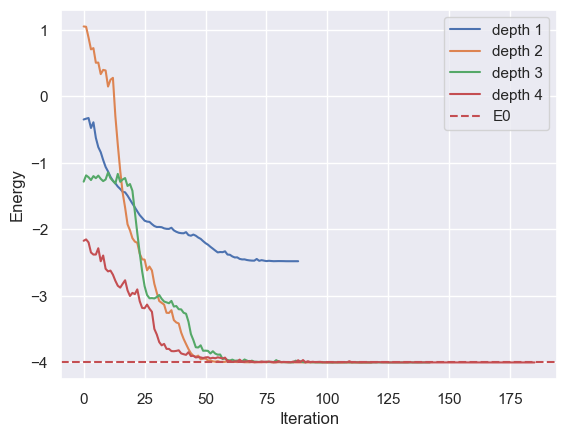

In [32]:
def callback(data):
                intermediate_info.append(data)
for i,opt_info in enumerate(energies):
    en=[]
    param=[]
    for info in opt_info:
        en.append(info[0])
        param.append(info[1])
    plt.plot(en,label=labels[i])
    plt.xlabel('Iteration')
    plt.ylabel('Energy')
plt.axhline(y=val0[0], color='r', linestyle='--',label='E0')
plt.legend()
plt.grid()
plt.savefig('Lipkin_cobyla_efficient_depth.pdf')
plt.show()

In [33]:
ansatzs=[Real_ansatz(2,1),Real_ansatz(2,2),Real_ansatz(2,3),Real_ansatz(2,4)]
labels=['depth 1','depth 2', 'depth 3','depth 4']
energies=[]
for ans in ansatzs:
    intermediate_info= []
    initial_parameters=np.random.rand(ans.num_parameters)*np.pi/2
    estimator = Estimator(options={'shots': None})
    H0,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    custom_vqe = QiskitVQE(estimator,ans,cobyla,H0,initial_parameters=initial_parameters,callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    energies.append(intermediate_info)


   Normal return from subroutine COBYLA

   NFVALS =   30   F =-1.999859E+00    MAXCV = 0.000000E+00
   X =-9.766964E-03   2.715479E-02

   Normal return from subroutine COBYLA

   NFVALS =   67   F =-3.999765E+00    MAXCV = 0.000000E+00
   X = 1.136355E+00   1.730755E+00   3.685931E-01   3.473763E+00   7.278011E-02
       1.064847E+00

   Normal return from subroutine COBYLA

   NFVALS =   96   F =-3.999948E+00    MAXCV = 0.000000E+00
   X = 5.728510E-01   8.909032E-01   2.041466E-01   9.670390E-01   1.761754E+00
       1.468477E+00   5.872980E-01   1.260263E+00   1.322364E+00   7.953249E-01

   Normal return from subroutine COBYLA

   NFVALS =   98   F =-3.999856E+00    MAXCV = 0.000000E+00
   X =-1.904363E-01   6.889841E-01   3.845505E-01   4.510654E-01   3.840177E-01
       8.457761E-01   9.186028E-01   8.866158E-01   9.503861E-01   5.322469E-01
       9.132620E-01   1.381241E+00   3.720798E-01  -2.347897E-01


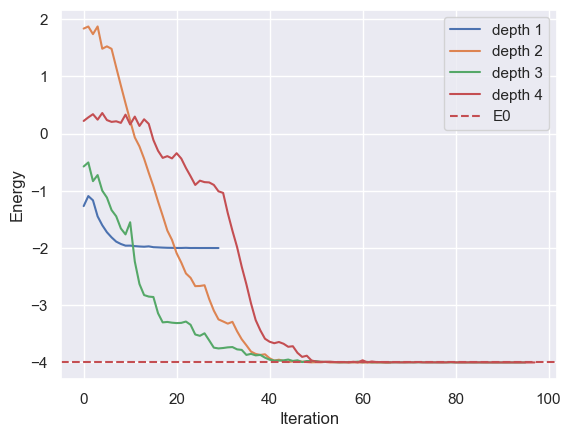

In [34]:
def callback(data):
                intermediate_info.append(data)
for i,opt_info in enumerate(energies):
    en=[]
    param=[]
    for info in opt_info:
        en.append(info[0])
        param.append(info[1])
    plt.plot(en,label=labels[i])
    plt.xlabel('Iteration')
    plt.ylabel('Energy')
plt.axhline(y=val0[0], color='r', linestyle='--',label='E0')
plt.legend()
plt.grid()
plt.savefig('Lipkin_cobyla_real_depth.pdf')
plt.show()

In [35]:
ansatzs=[Hamiltonian_ansatz(1),Hamiltonian_ansatz(2),Hamiltonian_ansatz(3),Hamiltonian_ansatz(4)]
labels=['depth 1','depth 2', 'depth 3','depth 4']
energies=[]
for ans in ansatzs:
    intermediate_info= []
    initial_parameters=np.ones(ans.num_parameters)*np.pi/2
    estimator = Estimator(options={'shots': None})
    H0,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    custom_vqe = QiskitVQE(estimator,ans,cobyla,H0,initial_parameters=initial_parameters,callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    energies.append(intermediate_info)


   Normal return from subroutine COBYLA

   NFVALS =  103   F =-3.999871E+00    MAXCV = 0.000000E+00
   X = 2.732424E+00   1.878853E+00   1.576314E+00   2.243226E+00   4.056399E-02
      -5.702477E-02   1.527524E+00

   Normal return from subroutine COBYLA

   NFVALS =  104   F =-3.999841E+00    MAXCV = 0.000000E+00
   X = 1.485446E+00   1.604275E+00   1.451465E+00   1.527311E+00   1.736479E+00
       2.916133E+00   1.587609E+00   1.770103E+00   1.716007E+00   1.504103E+00
       1.583416E+00   1.565383E+00   1.534883E+00   1.652266E+00

   Normal return from subroutine COBYLA

   NFVALS =  159   F =-3.999919E+00    MAXCV = 0.000000E+00
   X = 2.275014E+00   1.807389E+00   1.750635E+00   1.783172E+00   1.246962E+00
       1.479294E+00   1.127448E+00   1.530878E+00   1.405053E+00   1.164108E+00
       1.365777E+00   1.502256E+00   1.928470E+00   1.605404E+00   2.112743E+00
       1.790356E+00   1.557587E+00   1.693020E+00   1.021204E+00   1.293402E+00
       1.266109E+00

   Normal ret

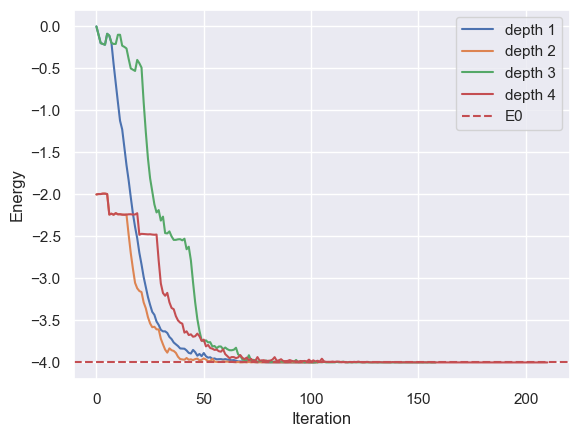

In [36]:
def callback(data):
                intermediate_info.append(data)
for i,opt_info in enumerate(energies):
    en=[]
    param=[]
    for info in opt_info:
        en.append(info[0])
        param.append(info[1])
    plt.plot(en,label=labels[i])
    plt.xlabel('Iteration')
    plt.ylabel('Energy')
plt.axhline(y=val0[0], color='r', linestyle='--',label='E0')
plt.legend()
plt.grid()

plt.show()

In [37]:
ansatzs=[separable_ansatz(2,1),separable_ansatz(2,2),separable_ansatz(2,3),separable_ansatz(2,4)]
labels=['depth 1','depth 2', 'depth 3','depth 4']
energies=[]
for ans in ansatzs:
    intermediate_info= []
    initial_parameters=np.random.rand(ans.num_parameters)*np.pi/2
    estimator = Estimator(options={'shots': None})
    H0,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    custom_vqe = QiskitVQE(estimator,ans,cobyla,H0,initial_parameters=initial_parameters,callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    energies.append(intermediate_info)


   Normal return from subroutine COBYLA

   NFVALS =   49   F =-3.808341E+00    MAXCV = 0.000000E+00
   X =-2.702615E-03  -1.363088E+00  -7.800044E-03  -4.152101E-01

   Normal return from subroutine COBYLA

   NFVALS =   70   F =-3.808348E+00    MAXCV = 0.000000E+00
   X = 1.423543E+00   1.381535E+00   2.307821E+00   5.385348E-01   1.592750E+00
       1.923753E+00   9.033841E-01   2.376221E+00

   Normal return from subroutine COBYLA

   NFVALS =  107   F =-3.808400E+00    MAXCV = 0.000000E+00
   X = 1.355136E+00   8.118568E-01   1.583771E+00   1.359575E-01   1.276412E+00
       1.215584E+00   1.352102E+00   1.186959E+00   7.479175E-01   8.877549E-01
       5.154184E-01   1.594797E+00

   Normal return from subroutine COBYLA

   NFVALS =  106   F =-3.808315E+00    MAXCV = 0.000000E+00
   X = 1.232537E+00   1.187699E+00   1.154567E+00   5.096650E-01  -1.386082E-03
       9.320323E-01   1.495475E+00   6.649304E-01   8.351785E-01   1.231135E+00
       9.607282E-01   1.526506E+00   7.492

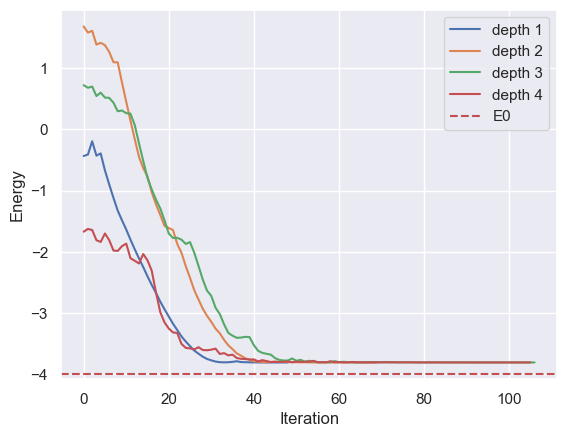

In [38]:
def callback(data):
                intermediate_info.append(data)
for i,opt_info in enumerate(energies):
    en=[]
    param=[]
    for info in opt_info:
        en.append(info[0])
        param.append(info[1])
    plt.plot(en,label=labels[i])
    plt.xlabel('Iteration')
    plt.ylabel('Energy')
plt.axhline(y=val0[0], color='r', linestyle='--',label='E0')
plt.legend()
plt.grid()
plt.savefig('Lipkin_cobyla_separable_depth.pdf')
plt.show()

In [39]:
ansatzs=[paper_ansatz(1),paper_ansatz(2),paper_ansatz(3),paper_ansatz(4)]
labels=['depth 1','depth 2', 'depth 3','depth 4']
energies=[]
for ans in ansatzs:
    intermediate_info= []
    initial_parameters=np.random.rand(ans.num_parameters)*np.pi/2
    estimator = Estimator(options={'shots': None})
    H0,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    custom_vqe = QiskitVQE(estimator,ans,cobyla,H0,initial_parameters=initial_parameters,callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    energies.append(intermediate_info)


   Normal return from subroutine COBYLA

   NFVALS =   39   F =-3.999890E+00    MAXCV = 0.000000E+00
   X =-1.454411E+00  -7.723008E-01

   Normal return from subroutine COBYLA

   NFVALS =  110   F =-3.997256E+00    MAXCV = 0.000000E+00
   X = 9.601424E-02   1.752877E+00  -1.491597E+00  -6.843043E-01

   Normal return from subroutine COBYLA

   NFVALS =   62   F =-3.999733E+00    MAXCV = 0.000000E+00
   X = 1.447776E+00   1.418461E-01   2.101802E+00  -1.475444E-01   1.308685E+00
      -5.840122E-01

   Normal return from subroutine COBYLA

   NFVALS =   79   F =-3.999110E+00    MAXCV = 0.000000E+00
   X =-7.802643E-01  -2.193958E-01  -6.392351E-01  -5.720859E-01  -1.203309E-01
      -6.823434E-02   1.023764E-01  -1.508299E-02


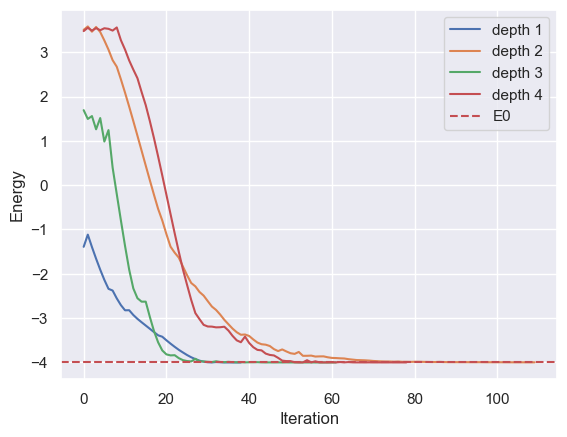

In [40]:
def callback(data):
                intermediate_info.append(data)
for i,opt_info in enumerate(energies):
    en=[]
    param=[]
    for info in opt_info:
        en.append(info[0])
        param.append(info[1])
    plt.plot(en,label=labels[i])
    plt.xlabel('Iteration')
    plt.ylabel('Energy')
plt.axhline(y=val0[0], color='r', linestyle='--',label='E0')
plt.legend()
plt.grid()
plt.show()

In [41]:
gs_real=[]
gs_eff=[]
gs_sep=[]
gs_paper=[]
gs_ham=[]
optimizer=cobyla
lambdas=np.arange(0.01,4/3,4/30)
infos=[]

ansatzs=[Real_ansatz(2,2),Efficient_ansatz(2,2),separable_ansatz(2,2),Hamiltonian_ansatz(2),paper_ansatz(2)]
initial_parameters=[np.ones(ansatzs[0].num_parameters)*np.pi/2,np.ones(ansatzs[1].num_parameters)*np.pi/2,np.ones(ansatzs[2].num_parameters)*np.pi/2,np.ones(ansatzs[3].num_parameters)*np.pi/2,np.ones(ansatzs[4].num_parameters)*np.pi/2]
for V in lambdas:
    intermediate_info= []
    
    estimator = Estimator(options={'shots': None})
    H,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    
    custom_vqe = QiskitVQE(estimator,ansatzs[0],optimizer,H,initial_parameters=initial_parameters[0],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_real.append(result)

    
    custom_vqe = QiskitVQE(estimator,ansatzs[1],optimizer,H,initial_parameters=initial_parameters[1],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_eff.append(result)


    custom_vqe = QiskitVQE(estimator,ansatzs[2],optimizer,H,initial_parameters=initial_parameters[2],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_sep.append(result)

    custom_vqe = QiskitVQE(estimator,ansatzs[3],optimizer,H,initial_parameters=initial_parameters[3],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_ham.append(result)

    custom_vqe = QiskitVQE(estimator,ansatzs[4],optimizer,H,initial_parameters=initial_parameters[4],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_paper.append(result)


   Normal return from subroutine COBYLA

   NFVALS =   46   F =-2.000204E+00    MAXCV = 0.000000E+00
   X = 1.330856E+00   2.046208E+00   1.371473E+00   2.287828E+00   2.482744E+00
       7.323993E-01

   Normal return from subroutine COBYLA

   NFVALS =  108   F =-2.000239E+00    MAXCV = 0.000000E+00
   X = 1.736359E+00   1.777467E+00   1.599076E+00   1.537986E+00   1.126475E+00
       1.387886E+00   1.490182E+00   9.563958E-01   1.573021E+00   1.036424E+00
       1.574301E+00   3.097123E+00

   Normal return from subroutine COBYLA

   NFVALS =   62   F =-2.000248E+00    MAXCV = 0.000000E+00
   X = 2.271972E+00   1.626505E+00   2.364820E+00   1.575825E+00   1.626732E+00
       2.410164E+00   1.571988E+00   2.348247E+00

   Normal return from subroutine COBYLA

   NFVALS =   45   F =-2.000129E+00    MAXCV = 0.000000E+00
   X = 1.572385E+00   1.574071E+00   1.573153E+00   1.575277E+00   1.575157E+00
       1.586215E+00   1.580447E+00   1.573901E+00   1.570268E+00   1.575090E+00
       


   Normal return from subroutine COBYLA

   NFVALS =  101   F =-3.445401E+00    MAXCV = 0.000000E+00
   X = 1.312885E+00   3.211760E+00   2.378689E-02   2.391270E+00

   Normal return from subroutine COBYLA

   NFVALS =   51   F =-3.831164E+00    MAXCV = 0.000000E+00
   X = 1.739199E+00   1.685043E+00   1.874206E+00   2.472464E+00   2.049732E+00
       6.585236E-01

   Normal return from subroutine COBYLA

   NFVALS =  148   F =-3.831207E+00    MAXCV = 0.000000E+00
   X = 1.515569E+00   1.750509E+00   9.975134E-01   1.642328E+00   2.108625E+00
       1.616932E+00   1.559915E+00   2.422878E+00   1.631956E+00   3.404429E+00
       1.624083E+00   2.377917E+00

   Normal return from subroutine COBYLA

   NFVALS =   55   F =-3.657640E+00    MAXCV = 0.000000E+00
   X = 1.680183E+00   1.549315E+00   2.208114E+00   1.568261E+00   1.567143E+00
       1.709710E+00   1.572402E+00   2.120153E+00

   Normal return from subroutine COBYLA

   NFVALS =  109   F =-3.831071E+00    MAXCV = 0.000000E+00


In [42]:
excited_real=[]
excited_eff=[]
excited_sep=[]
excited_paper=[]
excited_ham=[]
optimizer=cobyla
lambdas=np.arange(0.01,4/3,4/30)
infos=[]

ansatzs=[Real_ansatz(2,2),Efficient_ansatz(2,2),separable_ansatz(2,2),Hamiltonian_ansatz(2),paper_ansatz(2)]
initial_parameters=[np.ones(ansatzs[0].num_parameters)*np.pi/2,np.ones(ansatzs[1].num_parameters)*np.pi/2,np.ones(ansatzs[2].num_parameters)*np.pi/2,np.ones(ansatzs[3].num_parameters)*np.pi/2,np.ones(ansatzs[4].num_parameters)*np.pi/2]
for V in lambdas:
    intermediate_info= []
    
    estimator = Estimator(options={'shots': None})
    H,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    custom_vqe = QiskitVQE(estimator,ansatzs[0],optimizer,-H,initial_parameters=initial_parameters[0],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_real.append(-result)

    
    custom_vqe = QiskitVQE(estimator,ansatzs[1],optimizer,-H,initial_parameters=initial_parameters[1],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_eff.append(-result)


    custom_vqe = QiskitVQE(estimator,ansatzs[2],optimizer,-H,initial_parameters=initial_parameters[2],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_sep.append(-result)

    custom_vqe = QiskitVQE(estimator,ansatzs[3],optimizer,-H,initial_parameters=initial_parameters[3],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_ham.append(-result)

    custom_vqe = QiskitVQE(estimator,ansatzs[4],optimizer,-H,initial_parameters=initial_parameters[4],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_paper.append(-result)


   Normal return from subroutine COBYLA

   NFVALS =   47   F =-2.000246E+00    MAXCV = 0.000000E+00
   X = 1.257033E+00   9.143062E-01   1.353640E+00   9.321859E-01   8.347254E-01
       2.434134E+00

   Normal return from subroutine COBYLA

   NFVALS =  111   F =-2.000095E+00    MAXCV = 0.000000E+00
   X = 1.734268E+00   1.362770E+00   1.584020E+00   1.526657E+00   2.171508E+00
       1.441239E+00   1.611686E+00   2.023099E+00   1.602715E+00   2.098140E+00
       1.505781E+00   1.105780E-02

   Normal return from subroutine COBYLA

   NFVALS =   72   F =-2.000247E+00    MAXCV = 0.000000E+00
   X = 7.541969E-01   1.630300E+00   7.468887E-01   1.652590E+00   1.506350E+00
       8.048986E-01   1.478579E+00   7.962714E-01

   Normal return from subroutine COBYLA

   NFVALS =  134   F =-2.000244E+00    MAXCV = 0.000000E+00
   X = 1.736329E+00   1.634237E+00   2.498789E+00   2.808625E+00   1.610096E+00
       1.550656E+00   1.571998E+00   1.192318E+00   9.682589E-01   1.592795E+00
       


   Normal return from subroutine COBYLA

   NFVALS =  130   F =-3.830955E+00    MAXCV = 0.000000E+00
   X = 2.785633E+00   1.960456E+00   1.354341E+00   1.368694E+00   1.518000E+00
       2.508067E+00   6.877412E-01   1.254753E+00   1.328999E+00   1.931639E+00
       2.784442E+00   1.886465E+00

   Normal return from subroutine COBYLA

   NFVALS =   80   F =-3.657542E+00    MAXCV = 0.000000E+00
   X = 4.632100E-01   1.519660E+00   1.037688E-01   1.573011E+00   1.657325E+00
       7.160252E-01   1.623692E+00   1.391503E-01

   Normal return from subroutine COBYLA

   NFVALS =  166   F =-3.830868E+00    MAXCV = 0.000000E+00
   X = 2.086735E+00   2.429793E+00   1.255605E+00   9.543573E-01   1.218157E+00
       1.314213E-01   9.983716E-01   1.849191E+00   2.001815E+00   8.737764E-01
       1.298635E+00   1.816375E+00   1.878635E+00   1.576104E+00

   Normal return from subroutine COBYLA

   NFVALS =   74   F =-3.828266E+00    MAXCV = 0.000000E+00
   X = 1.411912E+00   1.255716E-01   1.262

In [43]:
lambdas_ex=np.arange(0.001,4/3,0.01)
vals_1=[]
for V in lambdas_ex:
    H,H1=Lipkin_J2_decomposition(E,V,W)
    val,vecs=np.linalg.eigh(H)
    vals_1.append(val)

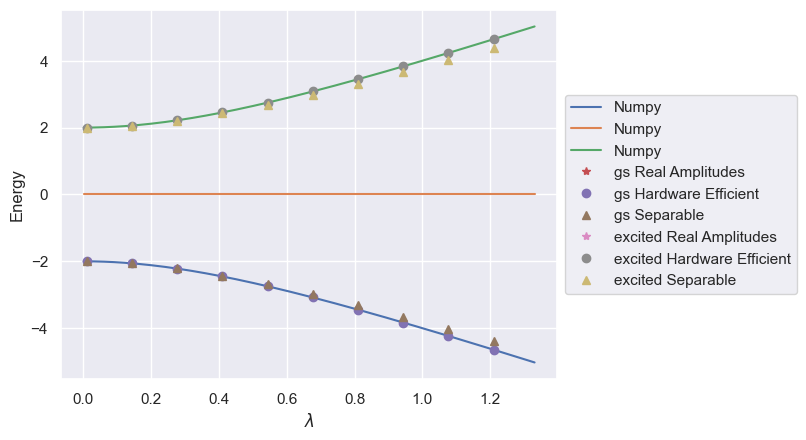

In [998]:
plt.plot(lambdas_ex,vals_1,label='Numpy')
plt.plot(lambdas,gs_real,linestyle='',marker='*',label='gs Real Amplitudes')
plt.plot(lambdas,gs_eff,linestyle='',marker='o',label='gs Hardware Efficient')
plt.plot(lambdas,gs_sep,linestyle='',marker='^',label='gs Separable')
#plt.plot(lambdas,gs_ham,linestyle='',marker='^',label='gs Hamiltonian')
#plt.plot(lambdas,gs_paper,linestyle='',marker='^',label='gs Paper')

plt.plot(lambdas,excited_real,linestyle='',marker='*',label='excited Real Amplitudes')
plt.plot(lambdas,excited_eff,linestyle='',marker='o',label='excited Hardware Efficient')
plt.plot(lambdas,excited_sep,linestyle='',marker='^',label='excited Separable')
#plt.plot(lambdas,excited_ham,linestyle='',marker='^',label='excited Hamiltonian')
#plt.plot(lambdas,excited_paper,linestyle='',marker='^',label='excited Paper')
plt.xlabel(r'$\lambda$')
plt.ylabel('Energy')
plt.grid()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('Lipkin_spsa_lambda_exact.pdf',bbox_inches='tight')
plt.show()

In [44]:
gs_real=[]
gs_eff=[]
gs_sep=[]
gs_paper=[]
gs_ham=[]
optimizer=cobyla
lambdas=np.arange(0.01,4/3,4/30)
infos=[]

ansatzs=[Real_ansatz(2,2),Efficient_ansatz(2,2),separable_ansatz(2,2),Hamiltonian_ansatz(2),paper_ansatz(2)]
initial_parameters=[np.ones(ansatzs[0].num_parameters)*np.pi/2,np.ones(ansatzs[1].num_parameters)*np.pi/2,np.ones(ansatzs[2].num_parameters)*np.pi/2,np.ones(ansatzs[3].num_parameters)*np.pi/2,np.ones(ansatzs[4].num_parameters)*np.pi/2]
for V in lambdas:
    intermediate_info= []
    
    estimator = Estimator(options={'shots': 10000})
    H,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    
    custom_vqe = QiskitVQE(estimator,ansatzs[0],optimizer,H,initial_parameters=initial_parameters[0],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_real.append(result)

    
    custom_vqe = QiskitVQE(estimator,ansatzs[1],optimizer,H,initial_parameters=initial_parameters[1],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_eff.append(result)


    custom_vqe = QiskitVQE(estimator,ansatzs[2],optimizer,H,initial_parameters=initial_parameters[2],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_sep.append(result)

    custom_vqe = QiskitVQE(estimator,ansatzs[3],optimizer,H,initial_parameters=initial_parameters[3],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_ham.append(result)

    custom_vqe = QiskitVQE(estimator,ansatzs[4],optimizer,H,initial_parameters=initial_parameters[4],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    gs_paper.append(result)


   Normal return from subroutine COBYLA

   NFVALS =   49   F =-1.999037E+00    MAXCV = 0.000000E+00
   X = 1.330629E+00   2.088335E+00   1.282395E+00   2.388453E+00   2.386332E+00
       8.443181E-01

   Normal return from subroutine COBYLA

   NFVALS =  115   F =-1.989874E+00    MAXCV = 0.000000E+00
   X = 1.193551E+00   1.321328E+00   1.687898E+00   1.312225E+00   1.089019E+00
       1.898178E+00   1.582490E+00   1.013706E+00   1.741859E+00   9.793886E-01
       1.681076E+00   2.965054E+00

   Normal return from subroutine COBYLA

   NFVALS =   62   F =-1.999180E+00    MAXCV = 0.000000E+00
   X = 2.147795E+00   1.836772E+00   2.106144E+00   1.559653E+00   1.724026E+00
       2.556944E+00   1.519922E+00   2.590693E+00

   Normal return from subroutine COBYLA

   NFVALS =   46   F =-1.999275E+00    MAXCV = 0.000000E+00
   X = 1.566872E+00   1.574173E+00   1.573192E+00   1.579091E+00   1.575128E+00
       1.561048E+00   1.573063E+00   1.564897E+00   1.575054E+00   1.571123E+00
       


   Normal return from subroutine COBYLA

   NFVALS =  118   F =-3.789607E+00    MAXCV = 0.000000E+00
   X = 1.437543E+00   1.439990E+00   7.530400E-01   1.801630E+00   2.466201E+00
       1.835904E+00   1.569049E+00   2.549269E+00   1.849576E+00   2.733378E+00
       1.847902E+00   2.032402E+00

   Normal return from subroutine COBYLA

   NFVALS =   49   F =-3.599873E+00    MAXCV = 0.000000E+00
   X = 1.567903E+00   1.579775E+00   2.078678E+00   1.553367E+00   1.515652E+00
       1.679796E+00   1.418499E+00   2.085749E+00

   Normal return from subroutine COBYLA

   NFVALS =  117   F =-3.818590E+00    MAXCV = 0.000000E+00
   X = 1.488112E+00   1.561721E+00   1.437485E+00   1.386711E+00   1.625017E+00
       2.807469E+00   1.670074E+00   1.576662E+00   1.768326E+00   1.453452E+00
       1.495482E+00   1.481909E+00   1.593527E+00   1.727081E+00

   Normal return from subroutine COBYLA

   NFVALS =   56   F =-3.814292E+00    MAXCV = 0.000000E+00
   X = 1.363578E+00   2.930236E+00   1.576

In [45]:
excited_real=[]
excited_eff=[]
excited_sep=[]
excited_paper=[]
excited_ham=[]
optimizer=cobyla
lambdas=np.arange(0.01,4/3,4/30)
infos=[]

ansatzs=[Real_ansatz(2,2),Efficient_ansatz(2,2),separable_ansatz(2,2),Hamiltonian_ansatz(2),paper_ansatz(2)]
initial_parameters=[np.ones(ansatzs[0].num_parameters)*np.pi/2,np.ones(ansatzs[1].num_parameters)*np.pi/2,np.ones(ansatzs[2].num_parameters)*np.pi/2,np.ones(ansatzs[3].num_parameters)*np.pi/2,np.ones(ansatzs[4].num_parameters)*np.pi/2]
for V in lambdas:
    intermediate_info= []
    
    estimator = Estimator(options={'shots': 10000})
    H,H1=Lipkin_J2_decomposition_Pauli(E,V,W)
    custom_vqe = QiskitVQE(estimator,ansatzs[0],optimizer,-H,initial_parameters=initial_parameters[0],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_real.append(-result)

    
    custom_vqe = QiskitVQE(estimator,ansatzs[1],optimizer,-H,initial_parameters=initial_parameters[1],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_eff.append(-result)


    custom_vqe = QiskitVQE(estimator,ansatzs[2],optimizer,-H,initial_parameters=initial_parameters[2],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_sep.append(-result)

    custom_vqe = QiskitVQE(estimator,ansatzs[3],optimizer,-H,initial_parameters=initial_parameters[3],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_ham.append(-result)

    custom_vqe = QiskitVQE(estimator,ansatzs[4],optimizer,-H,initial_parameters=initial_parameters[4],callback=callback)
    result = custom_vqe.compute_minimum_eigenvalue()
    infos.append(intermediate_info)
    excited_paper.append(-result)


   Normal return from subroutine COBYLA

   NFVALS =   51   F =-1.996695E+00    MAXCV = 0.000000E+00
   X = 1.167976E+00   1.087509E+00   1.452159E+00   8.492533E-01   7.243997E-01
       2.347548E+00

   Normal return from subroutine COBYLA

   NFVALS =  134   F =-1.999634E+00    MAXCV = 0.000000E+00
   X = 1.430047E+00   1.710722E+00   1.637656E+00   1.436575E+00   2.148278E+00
       1.752854E+00   1.443779E+00   2.128239E+00   1.531781E+00   1.987976E+00
       1.533449E+00   3.135390E-02

   Normal return from subroutine COBYLA

   NFVALS =   63   F =-2.000378E+00    MAXCV = 0.000000E+00
   X = 9.019515E-01   1.598677E+00   7.830875E-01   1.813480E+00   1.551954E+00
       6.605088E-01   1.370099E+00   7.270414E-01

   Normal return from subroutine COBYLA

   NFVALS =  103   F =-1.997539E+00    MAXCV = 0.000000E+00
   X = 1.717195E+00   1.619113E+00   2.478632E+00   2.562549E+00   1.640855E+00
       1.514327E+00   1.692684E+00   1.123154E+00   7.700330E-01   1.643476E+00
       


   Normal return from subroutine COBYLA

   NFVALS =  104   F =-1.684853E+00    MAXCV = 0.000000E+00
   X = 1.685472E+00   1.414594E+00   1.422025E+00   1.678865E+00   1.724244E+00
       2.410316E+00   1.173400E+00   1.349668E+00   1.523342E+00   1.878684E+00
       2.200289E+00   2.886774E+00

   Normal return from subroutine COBYLA

   NFVALS =   89   F =-3.611055E+00    MAXCV = 0.000000E+00
   X = 8.822514E-01   1.842895E+00   1.776022E-01   1.385158E+00   1.389299E+00
       4.385969E-01   1.961353E+00   1.323079E-01

   Normal return from subroutine COBYLA

   NFVALS =  153   F =-3.830838E+00    MAXCV = 0.000000E+00
   X = 1.668495E+00   1.449182E+00   8.386853E-01   1.395055E+00   6.917429E-01
      -5.185945E-01   1.907510E+00   1.768451E+00   2.368410E+00   1.310719E+00
       1.294394E+00   1.253437E+00   1.304755E+00   1.511456E+00

   Normal return from subroutine COBYLA

   NFVALS =   35   F =-3.698462E+00    MAXCV = 0.000000E+00
   X = 1.093723E+00   1.009386E+00   1.602

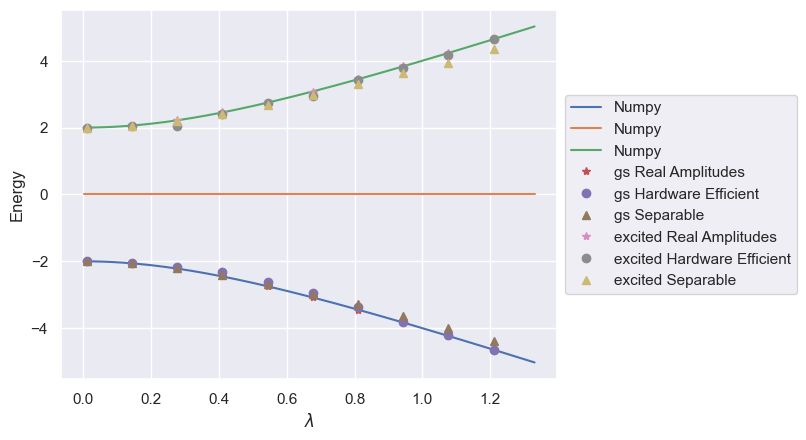

In [1001]:
plt.figure()
plt.plot(lambdas_ex,vals_1,label='Numpy')
plt.plot(lambdas,gs_real,linestyle='',marker='*',label='gs Real Amplitudes')
plt.plot(lambdas,gs_eff,linestyle='',marker='o',label='gs Hardware Efficient')
plt.plot(lambdas,gs_sep,linestyle='',marker='^',label='gs Separable')
#plt.plot(lambdas,gs_ham,linestyle='',marker='^',label='gs Hamiltonian')
#plt.plot(lambdas,gs_paper,linestyle='',marker='^',label='gs Paper')

plt.plot(lambdas,excited_real,linestyle='',marker='*',label='excited Real Amplitudes')
plt.plot(lambdas,excited_eff,linestyle='',marker='o',label='excited Hardware Efficient')
plt.plot(lambdas,excited_sep,linestyle='',marker='^',label='excited Separable')
#plt.plot(lambdas,excited_ham,linestyle='',marker='^',label='excited Hamiltonian')
#plt.plot(lambdas,excited_paper,linestyle='',marker='^',label='excited Paper')
plt.xlabel(r'$\lambda$')
plt.ylabel('Energy')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.grid()
plt.savefig('Lipkin_spsa_lambda_10000.pdf',bbox_inches='tight')
plt.show()